In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [32]:
df = pd.read_csv("../data/processed/cleaned_retail_data.csv")

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14.]),
 [Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12'),
  Text(14.0, 0, '14')])

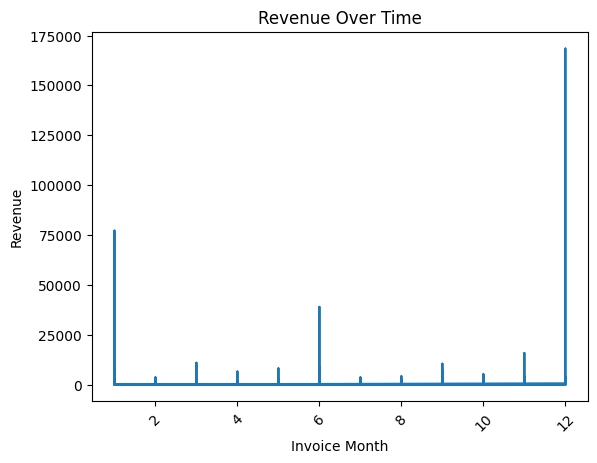

In [33]:
plt.plot(df['InvoiceMonth'], df['TotalPrice'])
plt.xlabel("Invoice Month")
plt.ylabel("Revenue")
plt.title("Revenue Over Time")
plt.xticks(rotation=45)

In [34]:
country_revenue = (
    df.groupby("Country")["TotalPrice"]
    .sum()
    .sort_values(ascending=False)
)

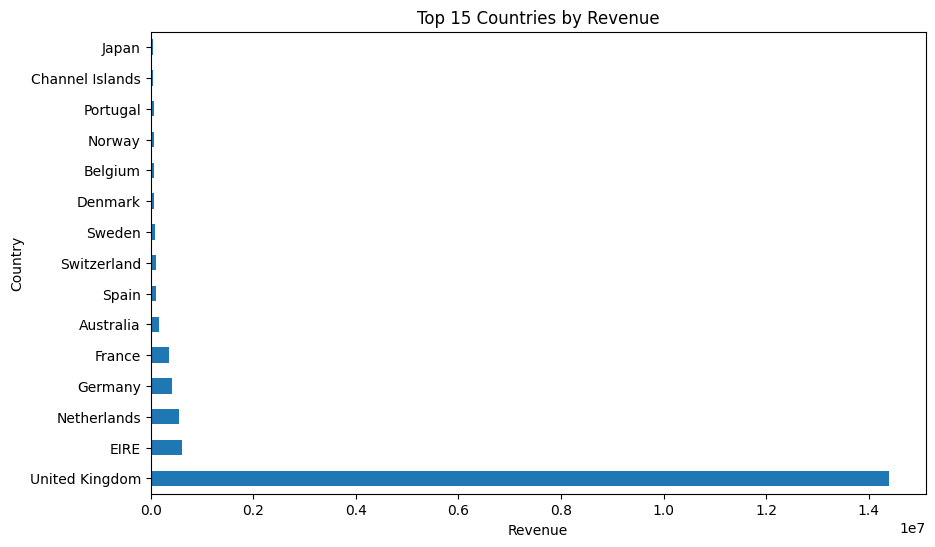

In [35]:
import matplotlib.pyplot as plt

country_revenue.head(15).plot(
    kind="barh",
    figsize=(10, 6)
)

plt.xlabel("Revenue")
plt.ylabel("Country")
plt.title("Top 15 Countries by Revenue")

plt.show()

In [36]:
customer_revenue = (
    df.groupby("Customer ID")["TotalPrice"]
    .sum()
    .reset_index()
    .sort_values("TotalPrice", ascending=False)
)

customer_revenue.head()

,Customer ID,TotalPrice
5692,18102.0,580987.04
2277,14646.0,528602.52
1789,14156.0,313437.62
2538,14911.0,291420.81
5050,17450.0,244784.25


In [37]:
customer_revenue.head(10)

,Customer ID,TotalPrice
5692,18102.0,580987.04
2277,14646.0,528602.52
1789,14156.0,313437.62
2538,14911.0,291420.81
5050,17450.0,244784.25
1331,13694.0,195640.69
5109,17511.0,172132.87
4061,16446.0,168472.50
4295,16684.0,147142.77
68,12415.0,144458.37


In [38]:
avg_spend = customer_revenue["TotalPrice"].mean()

print(avg_spend)

2955.9040945899965


In [39]:
median_spend = customer_revenue["TotalPrice"].median()

print(median_spend)

867.74


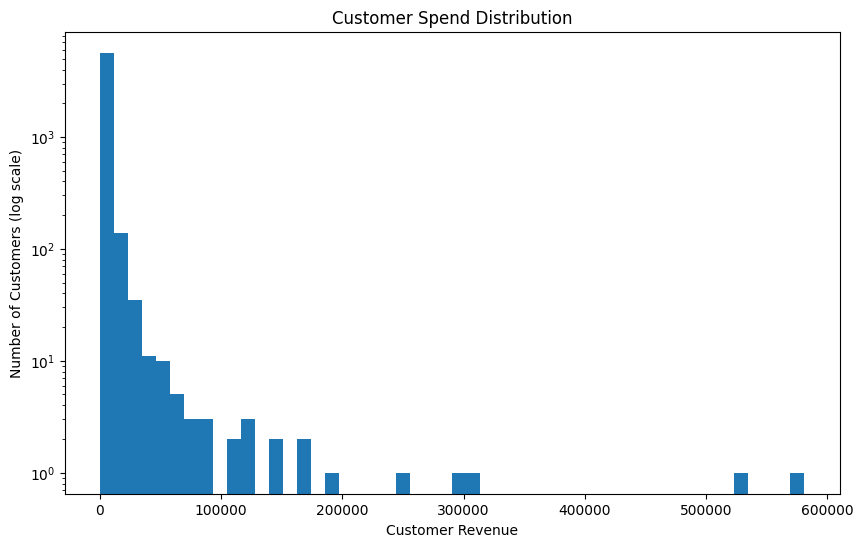

In [40]:
plt.figure(figsize=(10,6))

plt.hist(
    customer_revenue["TotalPrice"],
    bins=50,
    log=True
)

plt.xlabel("Customer Revenue")
plt.ylabel("Number of Customers (log scale)")
plt.title("Customer Spend Distribution")

plt.show()

In [41]:
top10_share = (
    customer_revenue.head(10)["TotalPrice"].sum()
    / customer_revenue["TotalPrice"].sum()
) * 100

print(top10_share)

16.040925681868522


In [42]:
top_n = int(len(customer_revenue) * 0.05)

top5_share = (
    customer_revenue.head(top_n)["TotalPrice"].sum()
    / customer_revenue["TotalPrice"].sum()
) * 100

print(top5_share)

51.949246706760086


In [43]:
df['Invoice'].nunique()

36969

In [64]:
#top 10 customers by number of orders
customer_orders = (
    df.groupby("Customer ID")["Invoice"]
    .nunique()
    .reset_index()
    .sort_values("Invoice", ascending=False)
).head(10)
print(customer_orders)

      Customer ID  Invoice
2538      14911.0      398
400       12748.0      336
5433      17841.0      211
2935      15311.0      208
739       13089.0      203
2237      14606.0      192
1789      14156.0      156
5442      17850.0      155
2277      14646.0      151
5692      18102.0      145


In [45]:
avg_orders = customer_orders["NumOrders"].mean()

print(avg_orders)

6.289384144266758


In [46]:
median_orders = customer_orders["NumOrders"].median()

print(median_orders)

3.0


In [47]:
max_orders = customer_orders["NumOrders"].max()

print(max_orders)

398


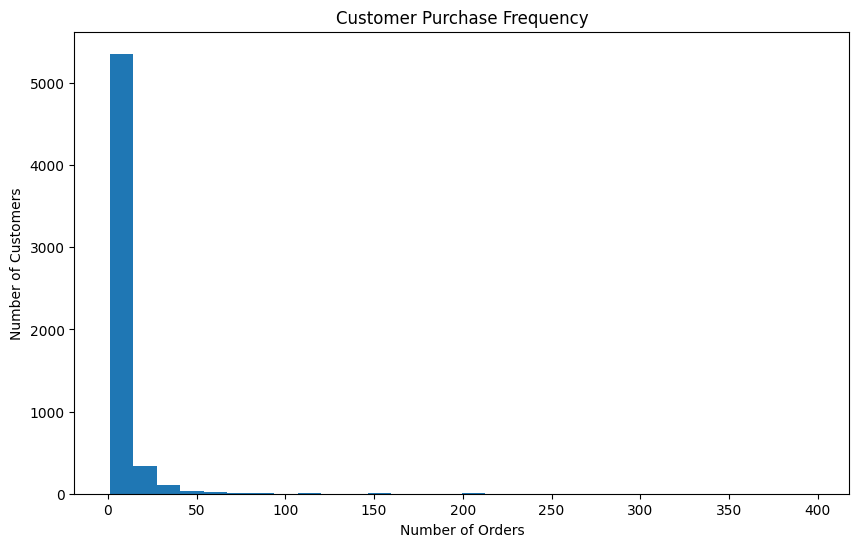

In [48]:

plt.figure(figsize=(10, 6))

plt.hist(
    customer_orders["NumOrders"],
    bins=30
)

plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")
plt.title("Customer Purchase Frequency")

plt.show()

In [49]:
one_time_buyers = (
    customer_orders["NumOrders"] == 1
).sum()

print(one_time_buyers)

1623


In [50]:
repeat_buyers = (
    customer_orders["NumOrders"] > 1
).sum()

print(repeat_buyers)

4255


In [51]:
total_customers = len(customer_orders)

one_time_pct = (
    one_time_buyers / total_customers
) * 100

repeat_pct = (
    repeat_buyers / total_customers
) * 100

print(one_time_pct)
print(repeat_pct)

27.611432460020414
72.38856753997959


In [52]:
loyal_customers = (
    customer_orders["NumOrders"] >= 5
).sum()

print(loyal_customers)

2161


In [53]:
top_10_prods = df.groupby("Description")["TotalPrice"].sum().sort_values(ascending=False).head(10)
top_10_prod = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
print(top_10_prods)
print(top_10_prod)

Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18
Name: TotalPrice, dtype: float64
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantit

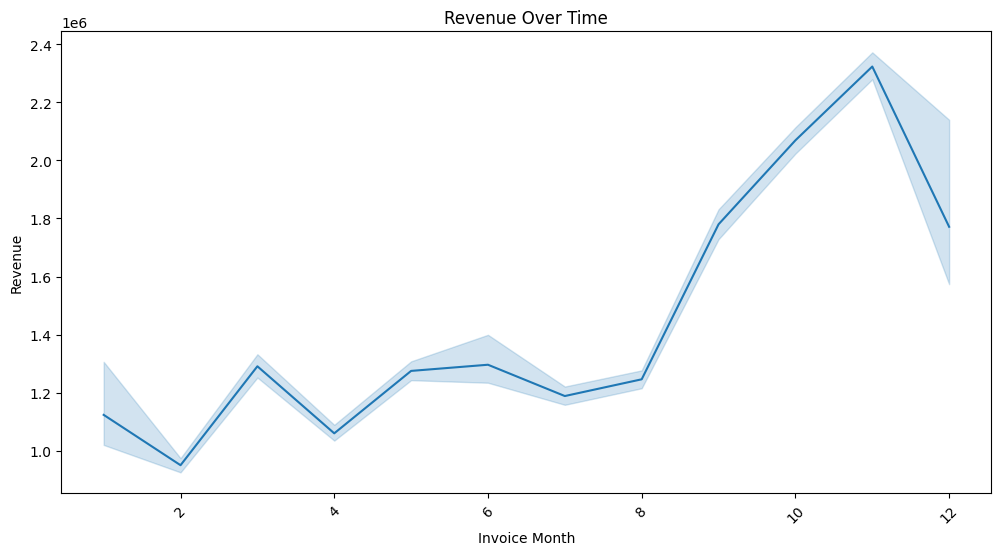

(1, 2, 3, 4, 5, 6, 7, 8, 9, 10)

In [60]:
#total revenue over time for each month using seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=df,
    x="InvoiceMonth",
    y="TotalPrice",
    estimator="sum",
)
plt.xlabel("Invoice Month")
plt.ylabel("Revenue")
plt.title("Revenue Over Time")
plt.xticks(rotation=45)
plt.show()


1, 2, 3, 4, 5, 6, 7, 8, 9, 10